## Overview 

This notebook pretrains the SSL encoder only on 70% benign training windows. 

Input window: **32 messages** 

Features: 

- **CAN_ID**: categorical embedding 
- **b0-b7, DLC, Δt**: numeric features
- **Δt** is log transformed before standarization 

During training, 30% of the message positions in each window are masked and reconstructed. 

The other 30% of the test windows will not be used for SSL training, and will be used later for the XGBoost evaluation pipeline. 


## 1. Setup 

### Imports

In [ ]:
import numpy as np 
from pathlib import Path 
import torch 
import torch.nn as nn 
from sklearn.preprocessing import StandardScaler
from torch.utils.data import Dataset, DataLoader, ConcatDataset 
from tqdm import tqdm

### Hyperparameters & paths

In [ ]:
SEED = 42 # Random seed for reproducibility
torch.manual_seed(SEED)

WINDOW_SIZE = 32
MASK_PROPORTION = 0.30 

BATCH_SIZE = 128 
NUM_EPOCHS = 15 
LEARNING_RATE = 0.0003 

CAN_EMBEDDING_DIM = 8 
DT_SCALE = 1_000_000.0  

BENIGN_WINDOWS = Path("..") / "Data" / "Benign_Windows"
ATTACK_WINDOWS = Path("..") / "Data" / "Attack_Windows"
MODEL_FOLDER = Path("models")
NPY_DIR = Path("embeddings")

device = torch.device("mps" if torch.backends.mps.is_available() 
                      else "cuda" if torch.cuda.is_available()
                      else "cpu")

print("Device:", device)



Device: mps


## 2. Data Loading 

### Benign Training Windows

In [ ]:
benign_train_paths = sorted(BENIGN_WINDOWS.glob("**/*_train.pt"))
benign_test_paths = sorted(BENIGN_WINDOWS.glob("**/*_test.pt"))

benign_train_windows = []

for path in benign_train_paths: 
    data = torch.load(path, map_location="cpu", weights_only=False)
    benign_train_windows.append(data["features"])
    
print("Training Files:", len(benign_train_windows))
print("Test Files:", len(benign_test_paths))
print("First Training Tensor:", benign_train_windows[0].shape)

Training Files: 3
Test Files: 3
First Training Tensor: torch.Size([429074, 32, 11])


## 3. Feature Preprocessing

### 3.1 CAN ID Vocabulary 

CAN ID needs to be treated as a category and not as a continuous number, since they represent identifiers and the model can get confused if one CAN ID is 700 and the other 800, it might think CAN ID 700 < 800 which its not the correct representation. 

INPUT TOKENS

Tokens are used as placeholders to represent special situations that are not regular CAN IDs.
For example, sometimes a CAN ID might be missing, hidden (for masking).  
Instead of using a default value like 0 which could be confused with a real CAN ID
we use special tokens. 

Allowing the embedding layer to learn a distinct representation for each situation.
This helps the model avoid confusion and improves its understanding of the data.

- MASK_ID: MASK ID token, represents the hidden CAN ID that will be used on the masking during SSL training. 

- UNK_ID: for CAN IDs not seen during benign SSL training 

In [ ]:
can_id_vocabulary = []

for tensor in benign_train_windows:
    ids_in_file = torch.unique(tensor[:, :, 0].long()).tolist()
    for can_id in ids_in_file:
        can_id_vocabulary.add(int(can_id))

can_id_vocabulary.sort()

can_id_to_index = {}
for index, can_id in enumerate(can_id_vocabulary):
    can_id_to_index[can_id] = index

NUM_CAN_IDS = len(can_id_vocabulary)
UNK_ID = NUM_CAN_IDS
MASK_ID = NUM_CAN_IDS + 1

print("Known benign CAN IDs:", NUM_CAN_IDS)
print("UNK_ID:", UNK_ID)
print("MASK_ID:", MASK_ID)

Known benign CAN IDs: 56
UNK_ID: 56
MASK_ID: 57


- 56 Unique CAN IDs, which are mapped internally to embedding indexes. 
- UNK_ID 56, used only for any CAN ID not present in the benign training vocabulary. 
- MASK_ID 57, used only during SSL masking, when a CAN ID is intetionally hidden as part of the 30% masking task, its embedding is replaced with 57.

In [5]:
for can_id, index in can_id_to_index.items():
    print(can_id, "->", index)

127 -> 0
304 -> 1
320 -> 2
339 -> 3
352 -> 4
356 -> 5
544 -> 6
593 -> 7
688 -> 8
832 -> 9
881 -> 10
882 -> 11
897 -> 12
902 -> 13
903 -> 14
905 -> 15
909 -> 16
916 -> 17
1040 -> 18
1042 -> 19
1056 -> 20
1057 -> 21
1078 -> 22
1136 -> 23
1151 -> 24
1157 -> 25
1168 -> 26
1173 -> 27
1186 -> 28
1191 -> 29
1225 -> 30
1265 -> 31
1280 -> 32
1287 -> 33
1290 -> 34
1291 -> 35
1292 -> 36
1294 -> 37
1312 -> 38
1322 -> 39
1342 -> 40
1345 -> 41
1348 -> 42
1355 -> 43
1363 -> 44
1369 -> 45
1407 -> 46
1426 -> 47
1427 -> 48
1429 -> 49
1430 -> 50
1456 -> 51
1470 -> 52
1473 -> 53
1507 -> 54
1535 -> 55


CAN ID is processed separately because it represents a categorical identity and will use an embedding layer. The remaining 10 features (b0-b7, DLC, and Δt) are numerical features. These are preprocessed and standardized before being combined with the CAN-ID embedding and passed to the SSL encoder.

In [ ]:
def convert_can_ids(raw_can_ids):
    # Convert CAN IDs to embedding indexes 
    can_id_indexes = []
    # Get the index of the CAN ID in the training vocabulary 
    for can_id in raw_can_ids.tolist():
        # If the CAN ID is not in the training vocabulary, use UNK_ID
        index = can_id_to_index.get(can_id, UNK_ID)
        can_id_indexes.append(index)
        
    # torch.long is used to store the indexes as integers 
    return torch.tensor(can_id_indexes, dtype=torch.long)

### 3.2 Numeric Features 

- **Payload bytes b0-b7**
- **DLC: Data Length of the Payload**
- **Δt Inter Arrival time**  Contains a lot of variation inside the data, meaning that it can affect the mean and standard deviation, so we compress this large range using a logarithm, converting the seconds to microseconds. 

Logarithmic transformation works well on very small timing values. 

Each feature has its own scale: 

Bytes = 0 to 255
DLC = around 0 to 8 
Δt = around 1e-6 to 0.001 seconds 

These numerical features are standardized before entering the model because they have very different value ranges. standardisation places them on comparable scales so that features with larger numerical values, such as payload bytes, do not dominate smaller features such as timing. 

Using the Z-score formula. 

In [ ]:
# Transform Δt 
def transform_delta(delta): 
    delta = delta.float()
    delta_microseconds = delta * DT_SCALE
    transformed_delta = torch.log1p(delta_microseconds)
    return transformed_delta

In [ ]:
scaler = StandardScaler()
all_windows = torch.cat(benign_train_windows, dim=0)
features = all_windows[:, :, 1:].float().clone()
# Transform the Δt column 
features[:, :, -1] = transform_delta(features[:, :, -1])
# Fit the scaler
scaler.fit(features.reshape(-1, 10).numpy())

# Mean
training_mean = torch.tensor(scaler.mean_, dtype=torch.float32)
# Standard deviation 
training_std = torch.tensor(scaler.scale_, dtype=torch.float32)

In [10]:
feature_names = [
    "b0", "b1", "b2", "b3",
    "b4", "b5", "b6", "b7",
    "DLC", "log_dt"
]

for i in range(len(feature_names)):

    print(
        feature_names[i],
        "| mean:", round(training_mean[i].item(), 4),
        "| std:", round(training_std[i].item(), 4)
    )

b0 | mean: 58.0659 | std: 77.6297
b1 | mean: 60.4033 | std: 77.4116
b2 | mean: 48.1177 | std: 72.989
b3 | mean: 61.4968 | std: 84.7441
b4 | mean: 47.9577 | std: 78.4898
b5 | mean: 53.5674 | std: 83.4639
b6 | mean: 33.8867 | std: 63.0744
b7 | mean: 53.2536 | std: 72.7697
DLC | mean: 7.303 | std: 1.4544
log_dt | mean: 2.6932 | std: 2.9822


We actually prepare the 10 numerical features of one (32,11) CAN window before giving it to the SSL model. Each of the 10 features is standardized using the previously calculated training_mean and training_std, which places the different feature types on similar scales while keeping the original patterns and differences between messages. 

b0-b7
- different means and variations
- expected because each payload position behaves differently

DLC
- centered near 7–8
- consistent with CAN traffic

log_dt
- no longer a extreme tiny raw number
- transformed into a normal scaled number 

In [11]:
def standardise_features(window):
    features = window[:, 1:].float().clone()
    # Apply the same transformation established earlier 
    features[:, -1] = transform_delta(features[:, -1])
    # Standarize the features
    standardised_features = (features - training_mean) / training_std 
    return standardised_features
    

### 3.3 Dataset & DataLoader 


The purpose of the Dataset is to automatically apply the CAN ID embeddings and the feature transformations whenever we process a window. 

The dataset succesfully prepares each training window while preserving its original 32 message structure. 

For each window we expect 32 CAN messages converted into categorical embedding indexes, plus the 10 processed numerical features. 

We have a total of 1,335,237 training windows across the thee benign training datasets. Which is treated as one whole training dataset without changing the structure of the individual windows. 

The dataloader groups the prepared dataset windows into batches for the model training. With a batch of size 128, each batch should contain 128 complete windows, with 32 CAN ID indexes and 32 sets of 10 numerical features per window. 


The DataLoader will shuffle the order in which the windows are selected during training, however it does not change the order of the 32 messages inside each window. 

In [ ]:
class BenignWindowDataset(Dataset): 
    
    def __init__(self, windows): 
        self.windows = windows
        
    def __len__(self): 
        return len(self.windows)
    
    def __getitem__(self, index): 
        
        window = self.windows[index]
        
        # Parse the CAN ID column 
        raw_can_ids = window[:, 0].long()
        # Convert CAN IDs to embedding indexes 
        can_id_indexes = convert_can_ids(raw_can_ids)
        
        # Prepare the 10 numerical features for that window 
        standardised_features = standardise_features(window)
        
        # Return the CAN ID indexes and the standardised features 
        return can_id_indexes, standardised_features         

In [ ]:
training_datasets = []

for file_windows in benign_train_windows:
    training_datasets.append(BenignWindowDataset(file_windows))

train_dataset = ConcatDataset(training_datasets)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

print("Total training windows:", len(train_dataset))
print(f"Batches per epoch: {len(train_loader)}")

CAN ID indexes: torch.Size([32])
Standardised features: torch.Size([32, 10])
Total training windows: 1335237


## 4. Model Architecture 

### 4.1 Input Representation

- Vocabulary size = 56 known IDs +  2 special tokens (UNK + MASK) → **58 rows**
- Each ID becomes an **8-dim** learned vector
- Shape: (128, 32) → (128, 32, 8)

This is concatenated with the 10 numeric features → **(128, 32, 18)** 
(8 embedding values + 10 features per message).

### 4.2 CNN Encoder 

Takes the (128, 32, 18) message features and learns local patterns across the 32 message window
(neighbouring IDs, payloads, timing).

**Conv1d** needs **(batch, channels, sequence)**, so we flip the order:
(128, 32, 18) → (128, 18, 32)

Two **Conv1d** layers (kernel_size=3, padding=1):
-  **kernel_size=3** looks at each message **and its neighbours**
-  **padding=1** keeps the sequence length at **32**
- channels go from **18 → 64**, so each position gets a richer learned representation

Shape: (128, 18, 32) → (128, 64, 32)

In [ ]:
class CNNEncoder(nn.Module): 
    
    def __init__(self): 
        super().__init__()
        
        self.conv1 = nn.Conv1d(
            in_channels=18, 
            out_channels=64,  # (128, 64, 32)
            kernel_size=3,  # local sequential relationships
            padding=1  # preserve the sequence length
        )
        
        # Deeper learned features 
        self.conv2 = nn.Conv1d(
            in_channels=64, 
            out_channels=64,
            kernel_size=3, 
            padding=1 
        )
        
        self.relu = nn.ReLU()
        
    def forward(self, cnn_input): 
        hidden_features = self.relu(self.conv1(cnn_input))
        encoded_features = self.relu(self.conv2(hidden_features))
        
        return encoded_features
        

### 4.3 Reconstruction Heads 

From the CNN output (128, 64, 32), two heads reconstruct the masked messages:

1. **CAN ID head** — predicts which of the 56 IDs was hidden  
   - loss: CrossEntropyLoss (on logits, no softmax needed)  
   - shape: (128, 64, 32) → (128, 32, 56)

2. **Numeric head** — predicts the 10 features (b0–b7, DLC, Δt)  
   - loss: MSELoss  
   - shape: (128, 64, 32) → (128, 32, 10)

Loss is computed **only on masked positions**.



In [ ]:
class CANIDReconHead(nn.Module): 
    
    def __init__(self): 
        
        super().__init__()
        
        self.can_id_prediction = nn.Conv1d(
            in_channels=64, 
            out_channels=56, 
            kernel_size=1 # 1D conv, 1D output
        )
        
    def forward(self, encoded_features): 
        # Conv1d: (batch, 64, 32) -> (batch, 56, 32)
        can_id_predictions = self.can_id_prediction(encoded_features)
        # CrossEntropy wants (batch, sequence, classes)
        can_id_predictions = can_id_predictions.permute(0, 2, 1)
        
        return can_id_predictions # logits 
    
# 56 scores per position; the largest score = predicted CAN ID

In [ ]:
class NumericReconHead(nn.Module): 
    
    def __init__(self): 
        
        super().__init__()
        
        self.feature_predictions = nn.Conv1d(
            in_channels=64,  
            out_channels=10,  
            kernel_size=1 # 1D conv, 1D output
        )
        
    def forward(self, encoded_features): 
        # Conv1d: (batch, 64, 32) -> (batch, 10, 32)
        feature_predictions = self.feature_predictions(encoded_features)
        feature_predictions = feature_predictions.permute(0,2,1) # (128, 10, 32) to (128, 32, 10) for MSE Loss
        
        return feature_predictions 
    

### 4.4 Complete SSL Model 

The complete SSL model combines all the components developed in the previous stages into one trainable architecture. 

1. **CAN ID embedding**  
   Each ID index (56 known + UNK + MASK = 58) becomes an 8 dim learned vector.

2. **Input representation**  
   Embedding is concatenated with the 10 numeric features → **(batch, 32, 18)** 
   (8 + 10 values describing each of the 32 messages).

3. From this shared encoded representation, the two reconstruction heads are used, the CAN ID head predicts one of the 56 known benign CAN ID classes, while the numerical head reconstructs the 10 masked numerical features. 

4. During SSL training, both reconstruction tasks will update the embedding and CNN encoder, making the model learn useful representations of normal CAN behaviour that can later be extracted and used as input features for the multiclass XGBoost classifier. 

**During SSL:** compare predictions to the original masked messages (loss → update model).  
**After SSL:** keep the encoder features, pool them to **192-dim** vectors, and use them for XGBoost.


In [ ]:
class SSLModel(nn.Module): 
    
    def __init__(self): 
        super().__init__()
        
        # CAN ID Embedding Layer
        self.can_embedding = nn.Embedding(num_embeddings=NUM_CAN_IDS + 2, embedding_dim=CAN_EMBEDDING_DIM)
        # CNN Encoder 
        self.encoder = CNNEncoder()
        # CAN ID Reconstruction Head
        self.can_id_head = CANIDReconHead()
        # Numerical Features Reconstruction Head
        self.numerical_head = NumericReconHead()
    
    # Forward pass which takes masked CAN IDs and features as input
    def forward(self, masked_can_ids, masked_features):   
        # Concatenate CAN IDs and features
        embedding_representation = torch.cat((self.can_embedding(masked_can_ids), masked_features), dim=2)
        # Flip the dimensions to match the expected input shape for the CNN
        cnn_input = embedding_representation.permute(0,2,1)
        # Pass through the CNN encoder
        encoded_features = self.encoder(cnn_input)
        # CAN ID Reconstruction
        can_id_predictions = self.can_id_head(encoded_features) # (batch,32,56)
        # Numerical Features Reconstruction
        feature_predictions = self.numerical_head(encoded_features) # (batch,32,10)
        return can_id_predictions, feature_predictions, encoded_features
    
ssl_model = SSLModel().to(device)
print(ssl_model)

SSLModel(
  (can_embedding): Embedding(58, 8)
  (encoder): CNNEncoder(
    (conv1): Conv1d(18, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (conv2): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (relu): ReLU()
  )
  (can_id_head): CANIDreconhead(
    (can_id_prediction): Conv1d(64, 56, kernel_size=(1,), stride=(1,))
  )
  (numerical_head): Numericalreconhead(
    (feature_predictions): Conv1d(64, 10, kernel_size=(1,), stride=(1,))
  )
)


## 5. SSL Training

### 5.1 Masking 

Self supervised learning objective of this project is to deliberately hide parts of each benign CAN window and ask the model to reconstruct the missing information. In order to do this approximately 30% of the 32 message positions in every window are randomly selected for masking. 

Since a window contains 32 messages, 10 message positions are masked, corresponding to the 30%. The masked positions change randomly during training so that the model learns relationships across the full CAN sequence rather than memorising fixed positions. 

The model must use the surrounding sequence context to reconstruct information from the 10 hidden positions. 

CAN ID = MASK_ID

numerical features = hidden representation

We mask the **whole message** at a position (CAN ID + all 10 numeric features), not just one field.

If only one field were hidden, the model could guess it from the other fields in that same message. That makes the task too easy.
By hiding the full message, the model must use the surrounding sequence (neighbouring IDs, payloads, and timing) to reconstruct it.

In [ ]:
positions_to_mask = round(WINDOW_SIZE * MASK_PROPORTION)

def mask_batch(can_id_batch, feature_batch):
    # Create a new mask for each window 
    window_mask = torch.zeros((len(can_id_batch), WINDOW_SIZE), dtype=torch.bool, device=device)
    
    # Loop through each window in the batch 
    for i in range(len(can_id_batch)):
        # Randomly select positions to mask 
        positions = torch.randperm(WINDOW_SIZE, device=device)[:positions_to_mask]
        window_mask[i, positions] = True
    
    # Make a copy of the CAN IDs and Features     
    masked_can_ids = can_id_batch.clone()
    masked_features = feature_batch.clone()
    
    # Mask the selected positions 
    masked_can_ids[window_mask] = MASK_ID
    masked_features[window_mask] = 0
    
    return masked_can_ids, masked_features, window_mask     

### 5.2 Loss

Loss is computed **only on masked positions** (~30% of each window).

- CAN ID: **CrossEntropyLoss** (56 classes) Which of the 56 CAN IDs is correct?
- Numeric features: **MSELoss** (10 values) How close are the predicted values to the original values? 
- Total: **CAN ID Loss Weight * can_loss + Feature Loss Weight * feature_loss**

Each batch has 128 windows, and we mask ~30% of the 32 positions → **10 masks per window**.  
So the loss is computed on about **128 × 10 = 1280** positions per batch (not on the full 4096 messages).


In [ ]:
can_loss_function = nn.CrossEntropyLoss()
feature_loss_function = nn.MSELoss()

def calculate_loss(can_id_batch, feature_batch): 
    # Uses the mask batch function to prepare the batch for the SSL task 
    masked_can_ids, masked_features, window_mask = mask_batch(can_id_batch, feature_batch)
    
    # Pass the masked inputs through the SSL model to predict the missing CAN IDs 
    # and the numerical features 
    can_predictions, feature_predictions, _ = ssl_model(masked_can_ids, masked_features)
    
    # Calculate the loss only at the masked positions 
    can_loss = can_loss_function(can_predictions[window_mask], can_id_batch[window_mask])
    feature_loss = feature_loss_function(feature_predictions[window_mask], feature_batch[window_mask])
    
    # Combine the losses into a total SSL Loss 
    total_loss = 1.0 * can_loss + 1.0 * feature_loss
    
    # Return the individual losses and the total loss for later analysis 
    return can_loss, feature_loss, total_loss

### 5.3 Training Loop 

1. Train the SSL model for several epochs on the benign windows.

2. For each epoch, batch losses are reset, then every batch is moved to the device and passed through **calculate_loss()**. The total loss is backpropagated and the optimizer updates the model.

3. After each epoch, the average CAN ID, numeric, and total losses are stored so we can track whether reconstruction improves over time.

In [ ]:
# Initialise the optimizer 
optimizer = torch.optim.Adam(ssl_model.parameters(), lr=LEARNING_RATE)
# Initialise the final average loss of every epoch 
epoch_can_id_loss = []
epoch_feature_loss = []
epoch_total_loss = []

ssl_model.train()

for epoch in range(NUM_EPOCHS):

    # Counters that add together the losses from every batch in that epoch 
    can_loss_sum = 0
    feature_loss_sum = 0
    total_loss_sum = 0

    # Train on every batch
    for can_id_batch, feature_batch in tqdm(train_loader, desc=f"Epoch {epoch + 1}/{NUM_EPOCHS}"):
        can_id_batch = can_id_batch.to(device)
        feature_batch = feature_batch.to(device)

        can_id_loss, feature_loss, total_loss = calculate_loss(can_id_batch, feature_batch)

        optimizer.zero_grad() # reset the gradients 
        total_loss.backward() # backpropagate the loss, analyse how every parameter contributed to the error 
        optimizer.step() # update the model parameters using the gradients 

        # Add the losses from this batch to the running totals 
        # .item() converts the tensor to a python number 
        can_loss_sum += can_id_loss.item()
        feature_loss_sum += feature_loss.item()
        total_loss_sum += total_loss.item()
        
        # At the end of the epoch, these three variables contain the sum of all batch losses 

    # Calulates the average CAN ID loss for the entire epoch 
    epoch_can_id_loss.append(can_loss_sum / len(train_loader))
    # Calculates and stores the average numerical feature loss for the epoch 
    epoch_feature_loss.append(feature_loss_sum / len(train_loader))
    # Calculates the averag total loss for the entire epoch 
    epoch_total_loss.append(total_loss_sum / len(train_loader))

Epoch 15/15: 100%|██████████| 10432/10432 [04:32<00:00, 38.27it/s]


### 5.4 Save Model  & Load Model 

Save the trained weights so we do not need to retrain every time.  
Later we reload the same file for evaluation and for the encoder feature extraction.

In [31]:
torch.save(ssl_model.state_dict(), MODEL_FOLDER / "ssl_model_15.pth")

In [32]:
ssl_model = SSLModel().to(device)
ssl_model.load_state_dict(torch.load(MODEL_FOLDER / "ssl_model_15.pth"))

<All keys matched successfully>

## 6. Evaluation

Evaluate the trained model’s reconstruction quality using the three SSL losses (CAN ID, numeric features, and total) on the training data.

### 6.1 Train Reconstruction Loss

In [33]:
ssl_model.eval() # Model in evaluation mode
 
# Average losses for the entire training set 
train_can_loss = 0   
train_feature_loss = 0
train_total_loss = 0

with torch.no_grad():

    for can_id_batch, feature_batch in tqdm(train_loader, desc="Training loss check"):
        can_id_batch = can_id_batch.to(device)
        feature_batch = feature_batch.to(device)

        can_loss, feature_loss, total_loss = calculate_loss(can_id_batch, feature_batch) # Calculate the loss for the batch 

        train_can_loss += can_loss.item() 
        train_feature_loss += feature_loss.item()
        train_total_loss += total_loss.item()


Training loss check: 100%|██████████| 10432/10432 [03:28<00:00, 49.95it/s]


In [34]:
train_can_loss = train_can_loss / len(train_loader)
train_feature_loss = train_feature_loss / len(train_loader)
train_total_loss = train_total_loss / len(train_loader)

print("CAN ID loss:", train_can_loss)
print("Feature loss:", train_feature_loss)
print("Total loss:", train_total_loss)

CAN ID loss: 0.9008759916960004
Feature loss: 0.5187367970163882
Total loss: 1.4196127889209365


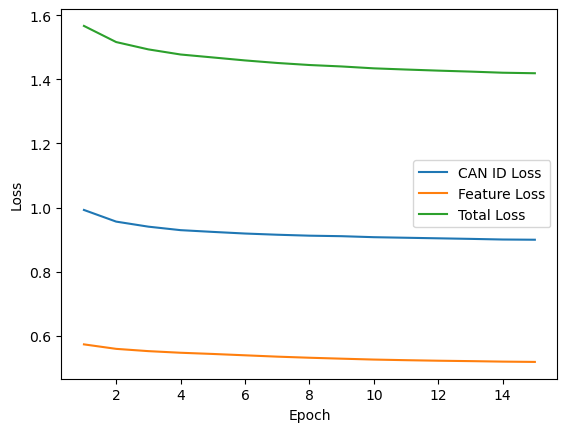

In [35]:
import matplotlib.pyplot as plt

epochs = range(1, NUM_EPOCHS + 1)

plt.plot(epochs, epoch_can_id_loss, label="CAN ID Loss")
plt.plot(epochs, epoch_feature_loss, label="Feature Loss")
plt.plot(epochs, epoch_total_loss, label="Total Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

### 6.2 Test Dataset 

In [ ]:
#### Load the test data 
test_windows = []
for pt_file in benign_test_paths:
    data = torch.load(pt_file, map_location="cpu", weights_only=False)
    test_windows.append(data["features"])
print("Test Files:", len(benign_test_paths))
print("First Test Tensor:", test_windows[0].shape)

Test Files: 3
First Test Tensor: torch.Size([183888, 32, 11])


We test the data the same way we trained it with the exception of the shuffle=False for consistent batch order. 

In [37]:
# Test dataset and dataloader 

# store one dataset for each test file 
test_datasets = []

for file_windows in test_windows:
    test_datasets.append(BenignWindowDataset(file_windows))

test_dataset = ConcatDataset(test_datasets)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

### 6.3 Test Reconstruction Loss

In [38]:
ssl_model.eval()

test_can_loss = 0 
test_feature_loss = 0 
test_total_loss = 0 

with torch.no_grad():
    
    for can_id_batch, feature_batch in tqdm(test_loader, desc="Testing"):
        can_id_batch = can_id_batch.to(device)
        feature_batch = feature_batch.to(device)
        
        can_loss, feature_loss, total_loss = calculate_loss(can_id_batch, feature_batch)
        
        test_can_loss += can_loss.item()
        test_feature_loss += feature_loss.item()
        test_total_loss += total_loss.item()

Testing: 100%|██████████| 4471/4471 [01:30<00:00, 49.36it/s]


In [39]:
test_can_loss = test_can_loss / len(test_loader)
test_feature_loss = test_feature_loss / len(test_loader)
test_total_loss = test_total_loss / len(test_loader)

print("Test CAN ID loss:", test_can_loss)
print("Test feature loss:", test_feature_loss)
print("Test total loss:", test_total_loss)

Test CAN ID loss: 0.9633586389376957
Test feature loss: 0.5284114215657152
Test total loss: 1.4917700606233932


## 7. Encoder Feature Extraction

After SSL training we keep the **encoder representation**, not the reconstruction heads.

For each window:
1. Run the model **without masking** → encoded features (batch, 64, 32) 
   (64 channels × 32 message positions)
2. Summarise over the 32 positions with mean, max, and std  
3. Concatenate them → one vector of size 64 × 3 = 192 per window

Pooling with **mean + max + std** keeps more information than mean alone:
- **mean** — typical behaviour in the window  
- **max** — strong / peak activations  
- **std** — how much the features vary across the 32 messages 

Together they form one **192-dim** vector (64 × 3) per window for XGBoost.

In [40]:
def extract_encoder(data_loader): 
    all_features = []
    
    with torch.no_grad(): 
        for can_ids, features in tqdm(data_loader, desc="Extracting features"): 
            can_ids = can_ids.to(device)
            features = features.to(device)
            
            # Runs the model on the batch on unmasked data 
            _, _, encoded_features = ssl_model(can_ids, features)
            
            # Encoded features are [batch_size, 64, 32]
            # We want to reduce them to [batch_size, 192] 
            mean_features = encoded_features.mean(dim=2)
            max_features = encoded_features.max(dim=2).values
            std_features = encoded_features.std(dim=2)            
            
            window_features = torch.cat([mean_features, max_features, std_features], dim=1)
            
            all_features.append(window_features.cpu())
        
    return torch.cat(all_features)

In [41]:
benign_encoder_features = extract_encoder(test_loader)

print("Encoder Feature Shape: ", benign_encoder_features.shape)

Extracting features: 100%|██████████| 4471/4471 [00:15<00:00, 281.58it/s]


Encoder Feature Shape:  torch.Size([572242, 192])


## 8. XGBoost Dataset Export

### 8.1 Attack Window Split

Encoder features from attack windows are labeled:
- **0** → DoS  
- **1** → Spoofing  
- **2** → Fuzzing  
- **3** → Replay  

This is done, because we can't use random split since the attacks where made with stride = 2, the windows overlap heavily. We need to leave 15 windows between train and test so that the last training window and first test window do not share orginal CAN messages. 

Original attack recording — chronological order

[-------------------- 70% --------------------][15-window gap][------ 30% ------]

             TRAIN                                           TEST


We keep stride = 2 to get **enough attack windows** from short injections. **A larger stride would reduce samples too much.** 

Instead, at the chronological 70/30 split we discard 15 windows so the train/test index gap is 16 (= window/stride), ensuring there are no **shared original CAN messages between the last train window and the first test window.**

In [42]:
GAP_WINDOWS = 15

def split_attack_windows(file_name): 
    
    # Load the attack window files
    data = torch.load(ATTACK_WINDOWS / f"{file_name}.pt", map_location="cpu", weights_only=False)
    
    # Extract the features from the file 
    windows = data["features"]
    labels = data["labels"]
    
    # Split the windows into train and test sets based on the 70% and 30% split 
    split_index = int(len(windows) * 0.70)
    
    # Split the train window from the beginnign of the file to the split index = 70% 
    train_windows = windows[:split_index]
    train_labels = labels[:split_index]
    
    # Split the rest of the window from the split index + 15 window gap = last part of the window 
    # which corresponds to the 30% of the file 
    test_windows = windows[split_index + GAP_WINDOWS:]
    test_labels = labels[split_index + GAP_WINDOWS:]
    
    return train_windows, train_labels, test_windows, test_labels

In [43]:
# Extract the features using the same BenignWindowDataset 
# because the attack window has to have the same format as the benign windows 
def get_encoder_features(windows): 
    dataset = BenignWindowDataset(windows)
    data_loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False)
    return extract_encoder(data_loader)

### 8.2 Extract Attack Encoder Features

For each attack file:
1. Split windows chronologically (70/30) with a gap so train and test do not overlap  
2. Pass both sides through the trained SSL encoder → 192 dim vectors  
3. Remap labels from **1–4 → 0–3** (XGBoost expects classes starting at 0)

We process one attack type at a time, then concatenate everything into the final **X_train / X_test** datasets.

In [ ]:
train_feature_sets = []
test_feature_sets = []

train_label_sets = []
test_label_sets = []

attack_files = [
    ATTACK_WINDOWS / "DoS_attack.pt",
    ATTACK_WINDOWS / "Steering_angle_attack.pt",
    ATTACK_WINDOWS / "Fuzzing_random_IDs.pt",
    ATTACK_WINDOWS / "EMS_replay_attack.pt",
]

for file_path in attack_files:
    # Extract the file name from the path 
    file_name = file_path.stem

    # Split the attack windows into train and test sets 
    train_windows, train_window_labels, test_windows, test_window_labels = split_attack_windows(file_name)

    # Extract the encoder features 
    train_encoder_features = get_encoder_features(train_windows)
    test_encoder_features = get_encoder_features(test_windows)
    
    # Append the features and labels to the lists 
    train_feature_sets.append(train_encoder_features)
    test_feature_sets.append(test_encoder_features)

    # Convert the labels to XGBoost labels 
    # Which means that the labels are now 0–3 instead of 1–4
    train_label_sets.append(train_window_labels)
    test_label_sets.append(test_window_labels)

    print(file_name, "| Train:", len(train_encoder_features), "| Test:", len(test_encoder_features))

Extracting features: 100%|██████████| 207/207 [00:00<00:00, 265.61it/s]


DoS_attack | Train: 61665 | Test: 26414


Extracting features: 100%|██████████| 148/148 [00:00<00:00, 269.86it/s]


Steering_angle_attack | Train: 44177 | Test: 18918


Extracting features: 100%|██████████| 283/283 [00:01<00:00, 270.18it/s]


Fuzzing_random_IDs | Train: 84513 | Test: 36205


Extracting features: 100%|██████████| 151/151 [00:00<00:00, 266.50it/s]

EMS_replay_attack | Train: 45075 | Test: 19303


### 8.3 XGBoost Numpy Datasets
- **X_train/test** → 192 dim encoder vectors  
- **y_train/test** → attack class (0–3)  

Shapes should look like **(n_windows, 192)** for **X** and **(n_windows,)** for **y**.

In [45]:
# Concatenate the features and labels 
X_train = torch.cat(train_feature_sets)
y_train = torch.cat(train_label_sets)

# Concatenate the test features and labels 
X_test = torch.cat(test_feature_sets)
y_test = torch.cat(test_label_sets)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: torch.Size([235430, 192])
y_train: torch.Size([235430])
X_test: torch.Size([100840, 192])
y_test: torch.Size([100840])


In [ ]:
for class_id in range(4):
    print(
        f"Class {class_id}: "
        f"Train {(y_train == class_id).sum().item()}, "
        f"Test {(y_test == class_id).sum().item()}"
    )

X_train = X_train.numpy()
y_train = y_train.numpy()
X_test = X_test.numpy()
y_test = y_test.numpy()

print(np.isnan(X_train).any())   
print(np.isinf(X_train).any())   

print("X_train:", X_train.shape, "| X_test:", X_test.shape)

np.save(NPY_DIR / "X_train_15.npy", X_train)
np.save(NPY_DIR / "y_train_15.npy", y_train)
np.save(NPY_DIR / "X_test_15.npy", X_test)
np.save(NPY_DIR / "y_test_15.npy", y_test)

print("Saved to:", NPY_DIR)

Class 0: Train 61665, Test 26414
Class 1: Train 44177, Test 18918
Class 2: Train 84513, Test 36205
Class 3: Train 45075, Test 19303
False
False
X_train: (235430, 192) | X_test: (100840, 192)
Saved to: ../New_XGBoost_Npy_Files
